## Multi-Model Post-Fire Landslide Probability Workflow

This notebook documents the post-fire Landlab workflow from gridded inputs to landslide-probability outputs. The expected pattern is that the upstream data pipeline prepares the required rasters and forcing files, and this notebook provides the execution layer for loading, checking, deriving, and running the model components.

The narrative is organized so imported layers appear before the derived fields that depend on them. That sequencing makes the workflow easier to audit, reproduce, and explain to external reviewers and agency users.


### Import Libraries and Components
Load plotting, numerical, Landlab, and custom hydro-ecologic components used throughout the workflow.

For a production-quality notebook, the main controls should live outside the notebook in a separate YAML or JSON config file. The key items to control are the input root path, layer file names, per-layer no-data values, forcing-file path, event window, and site/model constants.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

from landlab.components import SinkFillerBarnes, FlowAccumulator, DepressionFinderAndRouter, FlowDirectorMFD
from landlab.io import esri_ascii
from landlab.plot.imshow import imshow_grid
from landlab.plot.imshow import imshow_grid_at_node, imshow_grid_at_cell
from matplotlib.colors import ListedColormap

from landlab.components.landslides import LandslideProbability
#from landlab.components.mass_wasting_router.landslide_mapper import LandslideMapper as LM
from landlab.components.mass_wasting_runout import MassWastingRunout
from landlab.grid.mappers import map_node_to_cell
from potential_evapotranspiration_field_OFFICIAL import PotentialEvapotranspiration  
from radiation_field_OFFICIAL import Radiation 
from soil_moisture_dynamics import SoilMoisture
from recharge_routing import route_recharge_field

from pathlib import Path
from landlab.io import esri_ascii
import numpy as np

import numpy as np
import geopandas as gpd
import rasterio
from shapely.geometry import Point

import numpy as np
import rasterio
from landlab.io import write_esri_ascii


In [2]:
os.chdir("/mnt/c/Users/amehedi/Downloads/ml_debris/pioneer/output/cut1")
asc_dir = Path("/mnt/c/Users/amehedi/Downloads/ml_debris/pioneer/output/cut1")
dem_path = asc_dir / "topographic__elevation.asc" 

### DEM and Initialize Grid
Set the working data directory, load the DEM ASCII into a Landlab grid, define nodata and boundary conditions, and identify outlet and elevation bounds. The DEM path should be treated as a controlled input, not an ad hoc literal edited in multiple places.


In [3]:
with dem_path.open() as f:
    grid = esri_ascii.load(f, name="topographic__elevation", at="node")

Z = grid.at_node["topographic__elevation"]

grid.set_nodata_nodes_to_closed(Z, -999999)

# # outlet_id = grid.core_nodes[np.argmin(grid.at_node["topographic__elevation"][grid.core_nodes])]
# # grid.set_watershed_boundary_condition_outlet_id(outlet_id, Z)

Zmin = np.min(grid.at_node["topographic__elevation"][grid.core_nodes])
Zmax = np.max(grid.at_node["topographic__elevation"][grid.core_nodes])

# print("Outlet ID=", outlet_id)
# print("Outlet elevation=", grid.at_node["topographic__elevation"][outlet_id])
# print("Min elevation of core nodes=", Zmin)
# print("Max elevation of core nodes=", Zmax)

In [4]:
# Fill sinks to see if Flow Accumulator works better, this needs an outlet ID. if depression finder and router is used this step can be skipped, as long as the outlet drainge area is consisten with the area calculated above
# sfb = SinkFillerBarnes(grid,'topographic__elevation', method='D8', fill_flat = False,
#                       ignore_overfill = True)
# sfb.run_one_step()

# Low-elevation nodes to assign fixed value boundary condition
low_ids = np.where(
    (grid.status_at_node != grid.BC_NODE_IS_CLOSED) &
    (Z <= 337.0)
)[0]

grid.status_at_node[low_ids] = grid.BC_NODE_IS_FIXED_VALUE

fa = FlowAccumulator(
    grid,
    surface="topographic__elevation",
    flow_director="FlowDirectorD8",
    runoff_rate=None,
    depression_finder="DepressionFinderAndRouter",
)

da, q = fa.accumulate_flow()

In [5]:
# print('Number of nodes=', grid.number_of_nodes)
# print('Number of core nodes=', grid.number_of_core_nodes)

# cell_width=grid.dx
# cell_width

# print('Area_of_core_nodes km2=', grid.number_of_core_nodes*grid.dx*grid.dy/1000000)

# imshow_grid(grid,'topographic__elevation', plot_name = 'Topographic Elevation',
#             var_name = 'Elevation', var_units = 'm', grid_units = ('m','m'),
#             cmap = 'terrain')

# plt.show()

### Flow Routing and Derive Terrain Attributes
Fill sinks and run flow accumulation so drainage area and related flow-direction-dependent metrics are physically consistent. These routing products are derived from the imported DEM and support both the hydrologic and landslide calculations.


In [5]:
da = grid.at_node["drainage_area"]
print("min:", da.min(), "max:", da.max())
print("zeros:", np.sum(da == 0))
print("zeros on core nodes:", np.sum(da[grid.core_nodes] == 0))

min: 0.0 max: 94458600.00390625
zeros: 609874
zeros on core nodes: 0


In [6]:
logDA = np.log10(np.maximum(grid.at_node["drainage_area"], 1.0))
grid.add_field("log_drainage_area", logDA, at="node", clobber=True)

array([0., 0., 0., ..., 0., 0., 0.], shape=(968905,))

In [8]:
from landlab.io import write_esri_ascii

out_dir = "/mnt/c/Users/amehedi/Downloads/pioneer/output"

write_esri_ascii(f"{out_dir}/drainage_area.asc", grid, "drainage_area", clobber=True)
grid.add_field("log_drainage_area", np.log10(np.maximum(grid.at_node["drainage_area"], 1.0)), at="node", clobber=True)
write_esri_ascii(f"{out_dir}/log_drainage_area.asc", grid, "log_drainage_area", clobber=True)

['/mnt/c/Users/amehedi/Downloads/pioneer/output/log_drainage_area.asc']

### Terrain Attributes
Create and inspect terrain attributes such as slope, aspect, and hillshade. These derived terrain controls are central to runoff concentration and slope instability.


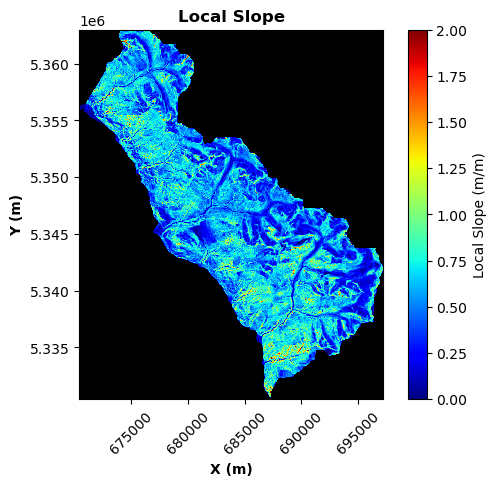

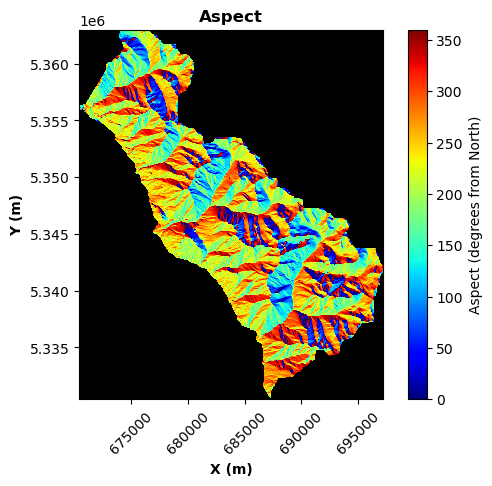

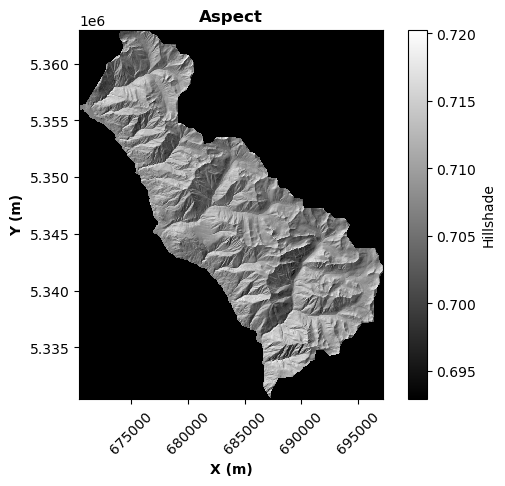

In [9]:
#Plotting slope, aspect, and hillshade
grid.add_field('topographic__slope', grid.at_node['topographic__steepest_slope'], at='node', clobber=True) ## used by the landslide model

imshow_grid(grid,'topographic__steepest_slope', plot_name = 'Local Slope',
            var_name = 'Local Slope', var_units = 'm/m', grid_units = ('m','m'),
            cmap = 'jet', limits=(0,2))
plt.title('Local Slope', fontweight='bold')
plt.xlabel('X (m)', fontweight='bold')
plt.ylabel('Y (m)', fontweight='bold')
plt.xticks(rotation=45)
plt.show()


aspect=grid.calc_aspect_at_node(elevs=Z)
slope=grid.calc_slope_at_node(elevs=Z)
hillshade=grid.calc_hillshade_at_node(elevs=Z, alt=45, az=315, slp=slope, asp=aspect)

_=grid.add_field('Aspect', aspect, at='node', clobber=True)
_=grid.add_field('Hillshade', hillshade, at='node', clobber=True)

#Aspect
imshow_grid(grid,'Aspect', plot_name = 'Aspect',
            var_name = 'Aspect', var_units = 'degrees from North', grid_units = ('m','m'),
            cmap = 'jet', limits=(0,360))
plt.title('Aspect', fontweight='bold')
plt.xlabel('X (m)', fontweight='bold')
plt.ylabel('Y (m)', fontweight='bold')
plt.xticks(rotation=45)
plt.show()

#Hillshade
imshow_grid(grid,'Hillshade', plot_name = 'Aspect',
            var_name = 'Hillshade', grid_units = ('m','m'),
            cmap = 'gray')
plt.title('Aspect', fontweight='bold')
plt.xlabel('X (m)', fontweight='bold')
plt.ylabel('Y (m)', fontweight='bold')
plt.xticks(rotation=45)
plt.show()

### Specific Contributing Area
Convert drainage area to specific contributing area (`topographic__specific_contributing_area`) for hydrologic response and slope-stability analysis.


In [10]:
cell_width=grid.dx

ca=grid.at_node['drainage_area']/cell_width  # now calculate SCA

_=grid.add_field('topographic__specific_contributing_area', ca, at='node', clobber=True)

### Load Soil Thickness
Import `soil__thickness` from ASCII, attach it to the grid, set nodata handling, and inspect spatial patterns. Soil thickness is an imported layer and should remain clearly separated from the derived fields computed later from it.


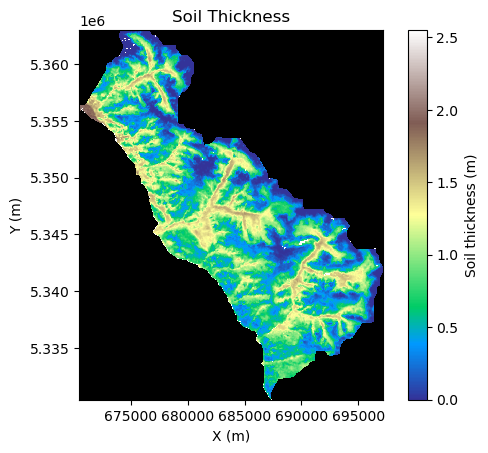

In [11]:
# Soil Thickness data from USDA SOLUS

with open("soil__thickness.asc") as f:
    hs_grid = esri_ascii.load(f, name="soil__thickness")

hs = hs_grid.at_node["soil__thickness"]

_=grid.add_field('soil__thickness', hs, at='node', clobber=True)   #SOLS data in cmm # investigate this

grid.set_nodata_nodes_to_closed(hs, 2.549999999999999822e+00)

imshow_grid(grid,'soil__thickness', plot_name = 'Soil Thickness',
            var_name = 'Soil thickness', var_units = 'm', grid_units = ('m','m'),
            cmap = 'terrain')

In [12]:
pd.Series(grid.at_node["soil__thickness"][grid.core_nodes]).describe()

count    358139.000000
mean          0.701599
std           0.435710
min           0.000000
25%           0.370000
50%           0.660000
75%           1.020000
max           2.550000
dtype: float64

In [13]:
hs = grid.at_node["soil__thickness"]
bad = grid.core_nodes[hs[grid.core_nodes] <= 0]

print("bad core nodes:", len(bad))
print("min core hs:", hs[grid.core_nodes].min())
print("sample bad values:", hs[bad][:20])

bad core nodes: 14179
min core hs: 0.0
sample bad values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [14]:
hs = grid.at_node["soil__thickness"]
mask = (grid.status_at_node != grid.BC_NODE_IS_CLOSED) & (hs <= 0)
hs[mask] = 0.01

###  Soil Density
Import `soil__density`, add it to the grid, close nodata nodes, and verify distribution with a map. Soil density is an imported mechanical property used later by the landslide component.


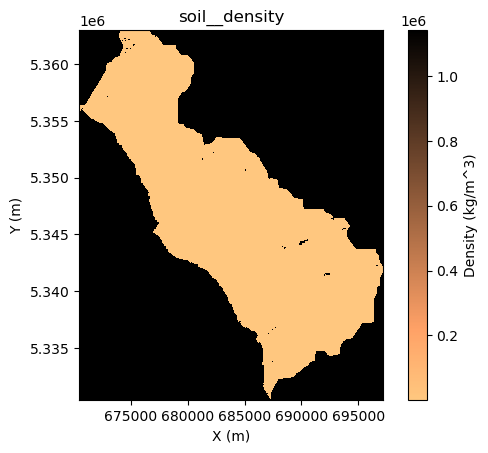

In [15]:
#Soil density data

with open("soil__density.asc") as f:
    ro_grid = esri_ascii.load(f, name="soil__density")

ro = ro_grid.at_node["soil__density"]

_=grid.add_field('soil__density', ro, at='node', clobber=True)

grid.set_nodata_nodes_to_closed(ro, 4.259999999999999898e-01)

imshow_grid_at_node(grid,'soil__density', plot_name = 'Soil Density',
            var_name = 'Density', var_units = 'kg/m^3', grid_units = ('m','m'),
            cmap = 'copper_r')

### Internal Friction Angle
Import `soil__internal_friction_angle` and register it as a node field for the landslide stability component.


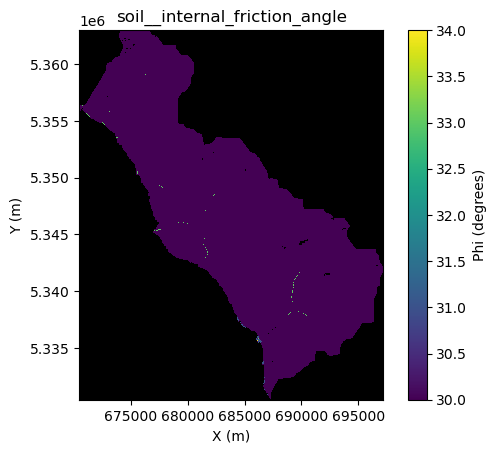

In [16]:
#Soil Internal friction angle from soil texture classification and look-up values from XX

with open("soil__internal_friction_angle.asc") as f:
    phi_grid = esri_ascii.load(f, name="soil__internal_friction_angle")

phi = phi_grid.at_node["soil__internal_friction_angle"]

_=grid.add_field('soil__internal_friction_angle', phi, at='node', clobber=True)

grid.set_nodata_nodes_to_closed(phi, 2.700000000000000000e+01)

imshow_grid_at_node(grid,'soil__internal_friction_angle', plot_name = 'Friction angle',
           var_name = 'Phi', var_units = 'degrees', grid_units = ('m','m'),
           cmap = 'viridis')

### Soil Hydraulic Properties
Import porosity, field capacity, wilting point, and saturated hydraulic conductivity, then add each as grid fields. These are imported soil layers, and their no-data values may vary by raster, so they should be controlled explicitly rather than assumed to match elevation.

These repetitive layer imports could be made more professional later with a small layer-specification dictionary plus a helper loader, while keeping the scientific logic unchanged.


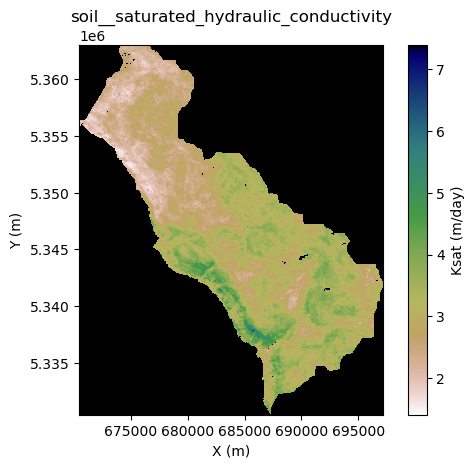

In [17]:
## Porosity

with open("porosity.asc") as f:
    n_grid = esri_ascii.load(f, name="porosity")

n = n_grid.at_node["porosity"]

_=grid.add_field('porosity', n, at='node', clobber=True)


## Field Capacity

with open("field__capacity.asc") as f:
    fc_grid = esri_ascii.load(f, name="field__capacity")

fc = fc_grid.at_node["field__capacity"]

_=grid.add_field('field__capacity', fc, at='node', clobber=True)


## Wilting Point

with open("wilting__point.asc") as f:
    wp_grid = esri_ascii.load(f, name="wilting__point")

wp = wp_grid.at_node["wilting__point"]

_=grid.add_field('wilting__point', wp, at='node', clobber=True)



## Saturated Hydraulic Conductivity

with open("soil__saturated_hydraulic_conductivity.asc") as f:
    ksat_grid = esri_ascii.load(f, name="soil__saturated_hydraulic_conductivity")

ksat = ksat_grid.at_node["soil__saturated_hydraulic_conductivity"]

_=grid.add_field('soil__saturated_hydraulic_conductivity', ksat, at='node', clobber=True)

grid.set_nodata_nodes_to_closed(ksat, 7.052563416309979523e+93)

imshow_grid_at_node(grid,'soil__saturated_hydraulic_conductivity', plot_name = 'Ksat',
            var_name = 'Ksat', var_units = 'm/day', grid_units = ('m','m'),
            cmap = 'gist_earth_r')

### Compute Transmissivity
Derive `soil__transmissivity` from imported conductivity and thickness, enforce a small positive floor, and map the result. This is a derived soil field and should be documented after the imported hydraulic layers that feed it.


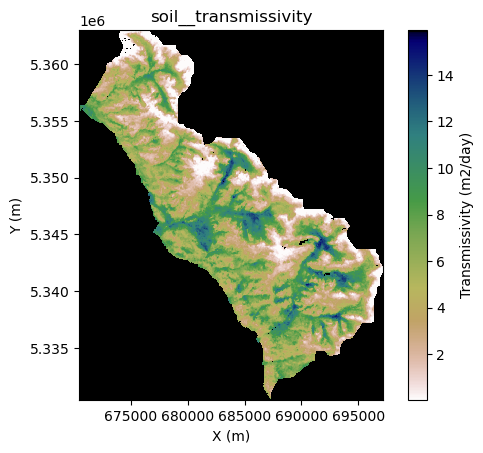

In [18]:
To=ksat*2.5*(hs) #m^2/day #To=ksat*2.5*(hs/100), anisotropic ratio- 
for i in range(len(To)):
    if To[i] <= 0:
        To[i] = 0.01

_=grid.add_field('soil__transmissivity', To, at='node',clobber=True)

imshow_grid_at_node(grid,'soil__transmissivity', plot_name = 'Transmissivity',
            var_name = 'Transmissivity', var_units = 'm2/day', grid_units = ('m','m'),
            cmap = 'gist_earth_r')

### Load Vegetation Functional Type
Import `vegetation__plant_functional_type`, cast to integer categories, and visualize the classified vegetation map.


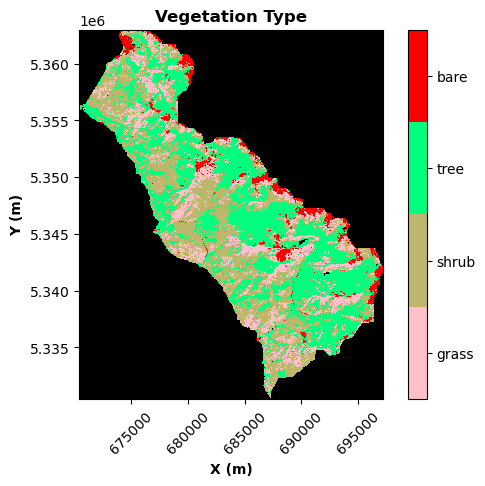

In [20]:
with open("vegetation__plant_functional_type.asc") as f:
    vt_grid = esri_ascii.load(f, name="vegetation__plant_functional_type")

vt = vt_grid.at_node["vegetation__plant_functional_type"]

_=grid.add_field('vegetation__plant_functional_type', vt, at='node', clobber=True)

grid.set_nodata_nodes_to_closed(vt, -9.999000000000000000e+03)

grid.add_field('vegetation__plant_functional_type', vt.astype(int), at='node', clobber=True)
imshow_grid_at_node(grid, 'vegetation__plant_functional_type', plot_name = 'Vegetation Type',
            cmap = ListedColormap(['pink',"darkkhaki", "springgreen", "red"], N=4), limits = (-0.5,3.5), allow_colorbar= False)
cb = plt.colorbar()
cb.set_ticks([0,1,2,3])
cb.set_ticklabels(['grass', 'shrub','tree','bare'])
plt.title('Vegetation Type', fontweight='bold')
plt.xlabel('X (m)', fontweight='bold')
plt.ylabel('Y (m)', fontweight='bold')
plt.xticks(rotation=45)
plt.show()

### Map Vegetation to Cells
Convert vegetation type from nodes to cells so ecohydrologic processes operating on cells receive the correct inputs.


In [21]:
# Map PFT from node to cell as the ecohydrology model operates on cells
grid['cell']['vegetation__plant_functional_type']=map_node_to_cell(grid, "vegetation__plant_functional_type").astype(int)
for i in range(len(grid['cell']['vegetation__plant_functional_type'])):
        if grid['cell']['vegetation__plant_functional_type'][i] < 0:
            grid['cell']['vegetation__plant_functional_type'][i] = 0

### Create Leaf Area Index Field
Assign LAI values by plant functional type and store `vegetation__live_leaf_area_index` for ecohydrology and evapotranspiration calculations.


In [22]:
LAI_grass = 1.5
LAI_shrub = 2.0
LAI_tree  = 4.0

## create or replace the field
grid.add_field('vegetation__live_leaf_area_index',
               np.zeros(grid.number_of_nodes, dtype=float),
               at='node', clobber=True)

pft = grid.at_node['vegetation__plant_functional_type']
lai = grid.at_node['vegetation__live_leaf_area_index']  # we can pass this directly

for i in range(grid.number_of_nodes):
    if pft[i] == 0:
        lai[i] = LAI_grass
    elif pft[i] == 1:
        lai[i] = LAI_shrub
    elif pft[i] == 2:
        lai[i] = LAI_tree
    elif pft[i] == 3:
        lai[i] = 1   ## default for bare

grid['cell']['vegetation__live_leaf_area_index']=map_node_to_cell(grid, "vegetation__live_leaf_area_index")

### Inspect LAI
Plot LAI at cell scale as a quality-control step before forcing the water-balance model.


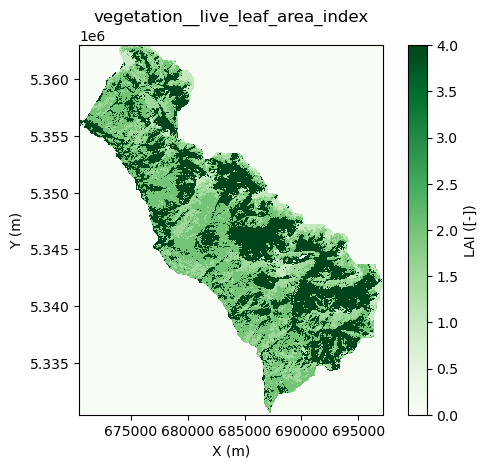

In [23]:
imshow_grid_at_cell(grid,'vegetation__live_leaf_area_index', plot_name = 'LAI',
            var_name = 'LAI', var_units = '[-]', grid_units = ('m','m'),
            cmap = 'Greens')

### Load Cohesion Surfaces
Import minimum, mode, and maximum root and soil cohesion fields from ASC inputs and attach them to the grid. These are imported strength layers and should remain distinguishable from any later scenario-based or post-fire modified cohesion surfaces.


In [24]:
with open("soil__maximum_total_cohesion.asc") as f:
    cmax_grid = esri_ascii.load(f, name="soil__maximum_total_cohesion")

cmax = cmax_grid.at_node["soil__maximum_total_cohesion"] 

_=grid.add_field('soil__maximum_total_cohesion', cmax, at='node', clobber=True)


with open("soil__mode_total_cohesion.asc") as f:
    cmode_grid = esri_ascii.load(f, name="soil__mode_total_cohesion")

cmode = cmode_grid.at_node["soil__mode_total_cohesion"]

_=grid.add_field('soil__mode_total_cohesion', cmode, at='node', clobber=True)

grid.set_nodata_nodes_to_closed(cmode, -9.999000000000000000e+03)


with open("soil__minimum_total_cohesion.asc") as f:
    cmin_grid = esri_ascii.load(f, name="soil__minimum_total_cohesion")

cmin = cmin_grid.at_node["soil__minimum_total_cohesion"]

_=grid.add_field('soil__minimum_total_cohesion', cmin, at='node', clobber=True)

grid.set_nodata_nodes_to_closed(cmax, -9.999000000000000000e+03)

In [25]:
# Descriptive stats of Soil Cohesion 

fields = [
    "soil__minimum_total_cohesion",
    "soil__mode_total_cohesion",
    "soil__maximum_total_cohesion",
]

rows = []
for f in fields:
    a = np.asarray(grid.at_node[f], dtype=float)[grid.core_nodes]
    a = a[np.isfinite(a)]
    rows.append({
        "field": f,
        "count": a.size,
        "min": np.min(a),
        "p25": np.percentile(a, 25),
        "mean": np.mean(a),
        "median": np.median(a),
        "p75": np.percentile(a, 75),
        "max": np.max(a),
        "std": np.std(a, ddof=1) if a.size > 1 else np.nan,
    })

pd.DataFrame(rows).set_index("field")

,count,min,p25,mean,median,p75,max,std
field,,,,,,,,
soil__minimum_total_cohesion,356990,4.8,1000.0,2019.972237,1690.0,2890.0,4000.0,1298.837878
soil__mode_total_cohesion,356990,16.0,2000.0,4694.054091,4000.0,7225.0,10000.0,3399.367743
soil__maximum_total_cohesion,356990,24.0,5000.0,10097.227997,8450.0,14450.0,20000.0,6492.556487


In [35]:
base_fields = [
    "soil__maximum_total_cohesion",
    "soil__mode_total_cohesion",
    "soil__minimum_total_cohesion",
]

reduction = {
    1: 0.00,  # Unburned
    2: 0.15,  # Low
    3: 0.35,  # Medium
    4: 0.60,  # High
}

burn = grid.at_node["burn__severity"].astype(int)

mult = np.ones(grid.number_of_nodes, dtype=float)
for cls, red in reduction.items():
    mult[burn == cls] = 1.0 - red

for base in base_fields:
    grid.at_node[base] = grid.at_node[base] / mult


### Load Burn Severity
Import `burn__severity` as a disturbance layer used to condition post-fire hydrologic interpretation and scenario testing.


In [26]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from landlab.io import write_esri_ascii

src_tif = "/mnt/c/Users/amehedi/Downloads/pioneer/pioneer_wa4818312053120240608_sbs.tif"
topo_tif = "/mnt/c/Users/amehedi/Downloads/ml_debris/pioneer/output/cut1/topographic__elevation.tif"
out_asc = "/mnt/c/Users/amehedi/Downloads/burn__severity.asc"
out_tif = "/mnt/c/Users/amehedi/Downloads/burn__severity.tif"

with rasterio.open(topo_tif) as topo:
    dst_shape = (topo.height, topo.width)
    dst_transform = topo.transform
    dst_crs = topo.crs
    profile = topo.profile.copy()

with rasterio.open(src_tif) as src:
    burn = np.zeros(dst_shape, dtype=np.uint8)
    reproject(
        source=rasterio.band(src, 1),
        destination=burn,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        src_nodata=src.nodata,
        dst_nodata=0,
        resampling=Resampling.nearest,
    )

burn[burn == 15] = 0

with rasterio.open(
    out_tif,
    "w",
    **{**profile, "dtype": burn.dtype, "count": 1, "nodata": 0},
) as dst:
    dst.write(burn, 1)

with rasterio.open(out_tif) as src:
    arr = src.read(1)

with open(out_asc, "w") as f:
    f.write(f"ncols         {src.width}\n")
    f.write(f"nrows         {src.height}\n")
    f.write(f"xllcorner     {src.transform.c}\n")
    f.write(f"yllcorner     {src.transform.f + src.height * src.transform.e}\n")
    f.write(f"cellsize      {src.transform.a}\n")
    f.write("NODATA_value  0\n")
    np.savetxt(f, arr, fmt="%d")

In [27]:
with open("/mnt/c/Users/amehedi/Downloads/burn__severity.asc") as f:
    bs_grid = esri_ascii.load(f, name="burn__severity")

grid.add_field("burn__severity", bs_grid.at_node["burn__severity"], at="node", clobber=True)

array([0., 0., 0., ..., 0., 0., 0.], shape=(968905,))

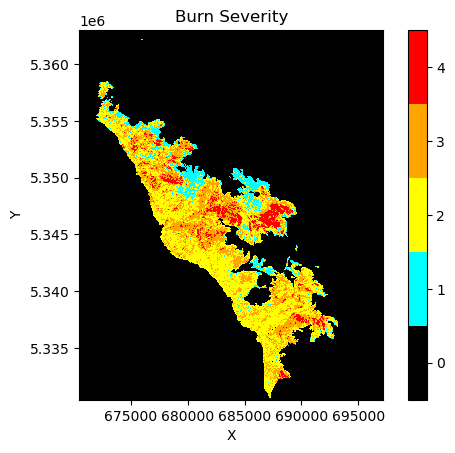

In [28]:
imshow_grid(
    grid,
    "burn__severity",
    at="node",
    plot_name="Burn Severity",
    cmap=ListedColormap(["black", "cyan", "yellow", "orange", "red"]),
    limits=(-0.5, 4.5),
)

plt.show()

### Update Total Soil Cohesion
This section is used for optional scenario-based cohesion modification, such as burn-severity-driven reductions. Keep the original imported cohesion surfaces conceptually distinct from any modified scenario layers so comparisons remain traceable.


In [36]:
out_dir = Path("/home/abdullah/fire-debrisflow-ml/data")

base_fields = [
    "soil__maximum_total_cohesion",
    "soil__mode_total_cohesion",
    "soil__minimum_total_cohesion",
]

reduction = {
    1: 0.00,  # Unburned
    2: 0.15,  # Low
    3: 0.35,  # Medium
    4: 0.60,  # High
}

burn = grid.at_node["burn__severity"].astype(int)

mult = np.ones(grid.number_of_nodes, dtype=float)
for cls, red in reduction.items():
    mult[burn == cls] = 1.0 - red

for base in base_fields:
    vals_mod = grid.at_node[base].copy() * mult

    grid.add_field(base, vals_mod, at="node", clobber=True)

    out_path = out_dir / f"{base}.asc"
    with open(out_path, "w") as f:
        esri_ascii.dump(grid, f, at="node", name=base)

print("Replaced original cohesion layers in:")
for b in base_fields:
    print(out_dir / f"{b}.asc")

Replaced original cohesion layers in:
/home/abdullah/fire-debrisflow-ml/data/soil__maximum_total_cohesion.asc
/home/abdullah/fire-debrisflow-ml/data/soil__mode_total_cohesion.asc
/home/abdullah/fire-debrisflow-ml/data/soil__minimum_total_cohesion.asc


In [37]:
# Descriptive stats of Soil Cohesion 

fields = [
    "soil__minimum_total_cohesion",
    "soil__mode_total_cohesion",
    "soil__maximum_total_cohesion",
]

rows = []
for f in fields:
    a = np.asarray(grid.at_node[f], dtype=float)[grid.core_nodes]
    a = a[np.isfinite(a)]
    rows.append({
        "field": f,
        "count": a.size,
        "min": np.min(a),
        "p25": np.percentile(a, 25),
        "mean": np.mean(a),
        "median": np.median(a),
        "p75": np.percentile(a, 75),
        "max": np.max(a),
        "std": np.std(a, ddof=1) if a.size > 1 else np.nan,
    })

pd.DataFrame(rows).set_index("field")

,count,min,p25,mean,median,p75,max,std
field,,,,,,,,
soil__minimum_total_cohesion,356990,4.8,1000.0,2019.972237,1690.0,2890.0,4000.0,1298.837878
soil__mode_total_cohesion,356990,16.0,2000.0,4694.054091,4000.0,7225.0,10000.0,3399.367743
soil__maximum_total_cohesion,356990,24.0,5000.0,10097.227997,8450.0,14450.0,20000.0,6492.556487


### Set Initial Soil Saturation
Compute `soil_moisture__initial_saturation_fraction` from imported field capacity, wilting point, and porosity, then map the result from nodes to cells. This is a derived initialization field, not a direct input raster.


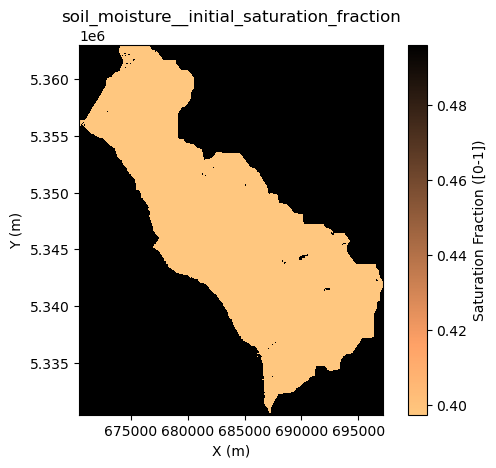

In [29]:
Saturation_fraction=(0.5*(grid.at_node['field__capacity']-grid.at_node['wilting__point'])+grid.at_node['wilting__point'])/grid.at_node['porosity']

_=grid.add_field('soil_moisture__initial_saturation_fraction', Saturation_fraction, at='node', clobber=True)

grid['cell']['soil_moisture__initial_saturation_fraction']=map_node_to_cell(grid, "soil_moisture__initial_saturation_fraction")

imshow_grid_at_node(grid,'soil_moisture__initial_saturation_fraction', plot_name = 'Saturation fraction',
            var_name = 'Saturation Fraction', var_units = '[0-1]', grid_units = ('m','m'),
            cmap = 'copper_r')

### Set PET and Radiation Site Constants
Define fixed site parameters such as latitude and albedo used by the radiation and potential evapotranspiration calculations. These should be treated as controlled parameters in a production workflow.

Meteorological Constants:
Define canopy height, wind reference height, wind speed, and relative humidity for PET and energy-balance calculations. These values should also be controlled inputs rather than hidden notebook literals.



In [30]:
Latitude=47.7
Albedo=0.2
Zveg=0.5 # vegetation height [m] 
Z_wind=2.0 # height at which wind speed was recorded. This should be above the canopy height
Vwind=3.04 # wind speed m/s
Relative_humidity=0.8 # relative humidity

### Build Daily Forcing Series
Create elevation-adjusted daily Tmin, Tmax, and precipitation forcing arrays using lapse-rate corrections and observed station data.

For reproducible event analysis, the preferred approach is to read forcing from an external time-series file and run an explicit storm window, for example a 7-day event, rather than rely on hardcoded values inside the notebook.


In [31]:
Zmin = np.min(grid.at_node["topographic__elevation"][grid.core_nodes])
Zmax = np.max(grid.at_node["topographic__elevation"][grid.core_nodes])

In [32]:
alpha = 4.5      # °C/km lapse rate
Zref = Zmin      # m, station elevation

expected_dates = pd.date_range("2025-12-07", "2025-12-20", freq="D")

base_dir = Path.cwd()
precip_path = base_dir / "precip_2026-01.csv"
temp_path = base_dir / "temp_2026-01.csv"

precip_df = pd.read_csv(precip_path, parse_dates=["datetime"])
temp_df = pd.read_csv(temp_path, parse_dates=["datetime"])

forcing_df = (
    temp_df.merge(precip_df, on="datetime", how="inner")
    .sort_values("datetime")
    .reset_index(drop=True)
)

if len(forcing_df) != len(expected_dates):
    raise ValueError(
        f"Expected {len(expected_dates)} daily records, found {len(forcing_df)}"
    )
if list(forcing_df["datetime"]) != list(expected_dates):
    raise ValueError("Forcing dates must span 2026-01-01 to 2026-01-31 with no gaps.")

Tmin_o = forcing_df["tmin_c"].tolist()   # C
Tmax_o = forcing_df["tmax_c"].tolist()   # C
P_obs = forcing_df["precip_mm"].tolist() # mm

rainfall_arrays = []
tempmin_arrays = []
tempmax_arrays = []

for _, row in forcing_df.iterrows():
    tmin_ref = row["tmin_c"]
    tmax_ref = row["tmax_c"]
    P_ref = row["precip_mm"]

    Tmax = tmax_ref - alpha * ((Z - Zref) / 1000.0)
    Tmin = tmin_ref - alpha * ((Z - Zref) / 1000.0)
    Ta   = ((tmin_ref + tmax_ref) / 2.0) - alpha * ((Z - Zref) / 1000.0)

    P_grid = np.full_like(Z, P_ref, dtype=float)

    rainfall_arrays.append(P_grid)
    tempmin_arrays.append(Tmin)
    tempmax_arrays.append(Tmax)

# Gridded precip and temp data 

In [33]:
from landlab.io import read_esri_ascii

dates = pd.date_range("2025-12-07", "2025-12-20", freq="D")

ppt_dir = asc_dir / "prism_daily_asc" / "ppt"
tmin_dir = asc_dir / "prism_daily_asc" / "tmin"
tmax_dir = asc_dir / "prism_daily_asc" / "tmax"

rainfall_arrays = []
tempmin_arrays = []
tempmax_arrays = []

for dt in dates:
    day = pd.Timestamp(dt).strftime("%Y%m%d")

    rain_path = ppt_dir / f"precip_{day}.asc"
    tmin_path = tmin_dir / f"tmin_{day}.asc"
    tmax_path = tmax_dir / f"tmax_{day}.asc"

    raingrid, P = read_esri_ascii(rain_path, name="Precipitation")
    tempmingrid, Tmin = read_esri_ascii(tmin_path, name="Temperature_min")
    tempmaxgrid, Tmax = read_esri_ascii(tmax_path, name="Temperature_max")

    rainfall_arrays.append(P.copy())
    tempmin_arrays.append(Tmin.copy())
    tempmax_arrays.append(Tmax.copy())

print(len(rainfall_arrays), len(tempmin_arrays), len(tempmax_arrays))
print(rainfall_arrays[0].shape, tempmin_arrays[0].shape, tempmax_arrays[0].shape)

/tmp/ipykernel_576135/3346341190.py:20: DeprecationWarning: landlab.io.read_asc_header has been deprecated, use landlab.io.esri_ascii.parse instead
  raingrid, P = read_esri_ascii(rain_path, name="Precipitation")
/tmp/ipykernel_576135/3346341190.py:21: DeprecationWarning: landlab.io.read_asc_header has been deprecated, use landlab.io.esri_ascii.parse instead
  tempmingrid, Tmin = read_esri_ascii(tmin_path, name="Temperature_min")
/tmp/ipykernel_576135/3346341190.py:22: DeprecationWarning: landlab.io.read_asc_header has been deprecated, use landlab.io.esri_ascii.parse instead
  tempmaxgrid, Tmax = read_esri_ascii(tmax_path, name="Temperature_max")


14 14 14
(968905,) (968905,) (968905,)


In [34]:
raingrid, P1 = read_esri_ascii(ppt_dir / "precip_20251207.asc", name="Precipitation")
raingrid, P2 = read_esri_ascii(ppt_dir / "precip_20251208.asc", name="Precipitation")
raingrid, P3 = read_esri_ascii(ppt_dir / "precip_20251209.asc", name="Precipitation")
raingrid, P4 = read_esri_ascii(ppt_dir / "precip_20251210.asc", name="Precipitation")
raingrid, P5 = read_esri_ascii(ppt_dir / "precip_20251211.asc", name="Precipitation")
raingrid, P6 = read_esri_ascii(ppt_dir / "precip_20251212.asc", name="Precipitation")
raingrid, P7 = read_esri_ascii(ppt_dir / "precip_20251213.asc", name="Precipitation")
raingrid, P8 = read_esri_ascii(ppt_dir / "precip_20251214.asc", name="Precipitation")
raingrid, P9 = read_esri_ascii(ppt_dir / "precip_20251215.asc", name="Precipitation")
raingrid, P10 = read_esri_ascii(ppt_dir / "precip_20251216.asc", name="Precipitation")
raingrid, P11 = read_esri_ascii(ppt_dir / "precip_20251217.asc", name="Precipitation")
raingrid, P12 = read_esri_ascii(ppt_dir / "precip_20251218.asc", name="Precipitation")
raingrid, P13 = read_esri_ascii(ppt_dir / "precip_20251219.asc", name="Precipitation")
raingrid, P14 = read_esri_ascii(ppt_dir / "precip_20251220.asc", name="Precipitation")

tempmingrid, Tmin1 = read_esri_ascii(tmin_dir / "tmin_20251207.asc", name="Temperature_min")
tempmingrid, Tmin2 = read_esri_ascii(tmin_dir / "tmin_20251208.asc", name="Temperature_min")
tempmingrid, Tmin3 = read_esri_ascii(tmin_dir / "tmin_20251209.asc", name="Temperature_min")
tempmingrid, Tmin4 = read_esri_ascii(tmin_dir / "tmin_20251210.asc", name="Temperature_min")
tempmingrid, Tmin5 = read_esri_ascii(tmin_dir / "tmin_20251211.asc", name="Temperature_min")
tempmingrid, Tmin6 = read_esri_ascii(tmin_dir / "tmin_20251212.asc", name="Temperature_min")
tempmingrid, Tmin7 = read_esri_ascii(tmin_dir / "tmin_20251213.asc", name="Temperature_min")
tempmingrid, Tmin8 = read_esri_ascii(tmin_dir / "tmin_20251214.asc", name="Temperature_min")
tempmingrid, Tmin9 = read_esri_ascii(tmin_dir / "tmin_20251215.asc", name="Temperature_min")
tempmingrid, Tmin10 = read_esri_ascii(tmin_dir / "tmin_20251216.asc", name="Temperature_min")
tempmingrid, Tmin11 = read_esri_ascii(tmin_dir / "tmin_20251217.asc", name="Temperature_min")
tempmingrid, Tmin12 = read_esri_ascii(tmin_dir / "tmin_20251218.asc", name="Temperature_min")
tempmingrid, Tmin13 = read_esri_ascii(tmin_dir / "tmin_20251219.asc", name="Temperature_min")
tempmingrid, Tmin14 = read_esri_ascii(tmin_dir / "tmin_20251220.asc", name="Temperature_min")

tempmaxgrid, Tmax1 = read_esri_ascii(tmax_dir / "tmax_20251207.asc", name="Temperature_max")
tempmaxgrid, Tmax2 = read_esri_ascii(tmax_dir / "tmax_20251208.asc", name="Temperature_max")
tempmaxgrid, Tmax3 = read_esri_ascii(tmax_dir / "tmax_20251209.asc", name="Temperature_max")
tempmaxgrid, Tmax4 = read_esri_ascii(tmax_dir / "tmax_20251210.asc", name="Temperature_max")
tempmaxgrid, Tmax5 = read_esri_ascii(tmax_dir / "tmax_20251211.asc", name="Temperature_max")
tempmaxgrid, Tmax6 = read_esri_ascii(tmax_dir / "tmax_20251212.asc", name="Temperature_max")
tempmaxgrid, Tmax7 = read_esri_ascii(tmax_dir / "tmax_20251213.asc", name="Temperature_max")
tempmaxgrid, Tmax8 = read_esri_ascii(tmax_dir / "tmax_20251214.asc", name="Temperature_max")
tempmaxgrid, Tmax9 = read_esri_ascii(tmax_dir / "tmax_20251215.asc", name="Temperature_max")
tempmaxgrid, Tmax10 = read_esri_ascii(tmax_dir / "tmax_20251216.asc", name="Temperature_max")
tempmaxgrid, Tmax11 = read_esri_ascii(tmax_dir / "tmax_20251217.asc", name="Temperature_max")
tempmaxgrid, Tmax12 = read_esri_ascii(tmax_dir / "tmax_20251218.asc", name="Temperature_max")
tempmaxgrid, Tmax13 = read_esri_ascii(tmax_dir / "tmax_20251219.asc", name="Temperature_max")
tempmaxgrid, Tmax14 = read_esri_ascii(tmax_dir / "tmax_20251220.asc", name="Temperature_max")

rainfall_arrays = [P1, P2, P3, P4, P5, P6, P7, P8, P9, P10, P11, P12, P13, P14]
tempmin_arrays = [Tmin1, Tmin2, Tmin3, Tmin4, Tmin5, Tmin6, Tmin7, Tmin8, Tmin9, Tmin10, Tmin11, Tmin12, Tmin13, Tmin14]
tempmax_arrays = [Tmax1, Tmax2, Tmax3, Tmax4, Tmax5, Tmax6, Tmax7, Tmax8, Tmax9, Tmax10, Tmax11, Tmax12, Tmax13, Tmax14]

/tmp/ipykernel_576135/3376971117.py:1: DeprecationWarning: landlab.io.read_asc_header has been deprecated, use landlab.io.esri_ascii.parse instead
  raingrid, P1 = read_esri_ascii(ppt_dir / "precip_20251207.asc", name="Precipitation")
/tmp/ipykernel_576135/3376971117.py:2: DeprecationWarning: landlab.io.read_asc_header has been deprecated, use landlab.io.esri_ascii.parse instead
  raingrid, P2 = read_esri_ascii(ppt_dir / "precip_20251208.asc", name="Precipitation")
/tmp/ipykernel_576135/3376971117.py:3: DeprecationWarning: landlab.io.read_asc_header has been deprecated, use landlab.io.esri_ascii.parse instead
  raingrid, P3 = read_esri_ascii(ppt_dir / "precip_20251209.asc", name="Precipitation")
/tmp/ipykernel_576135/3376971117.py:4: DeprecationWarning: landlab.io.read_asc_header has been deprecated, use landlab.io.esri_ascii.parse instead
  raingrid, P4 = read_esri_ascii(ppt_dir / "precip_20251210.asc", name="Precipitation")
/tmp/ipykernel_576135/3376971117.py:5: DeprecationWarning: l

In [35]:
print("n timesteps:", len(rainfall_arrays))
print("rain shape:", rainfall_arrays[0].shape)
print("tmin shape:", tempmin_arrays[0].shape)
print("tmax shape:", tempmax_arrays[0].shape)

n timesteps: 14
rain shape: (968905,)
tmin shape: (968905,)
tmax shape: (968905,)


In [36]:
if "rainfall__daily_depth" not in grid.at_cell:
    grid.add_ones("rainfall__daily_depth", at="cell")

grid.at_cell["rainfall__daily_depth"][:] = map_node_to_cell(grid, "Precipitation")

FieldError: Precipitation

### Run Daily Hydro-Eco Simulation
For each day, apply rainfall and temperature forcings, run Radiation, PET, and SoilMoisture components, and store runoff, recharge, soil-moisture, and evapotranspiration outputs.

This section controls the rainfall partition into interception, runoff, storage change, and root-zone leakage, so it directly controls the recharge signal later passed to the landslide model. Key controlled parameters include the forcing file, event window, input path, per-layer no-data values, and the site constants defined above.


In [37]:
t = 2
runoff_arrays=[]
recharge_arrays=[]
soil_moisture_arrays=[]
ET_arrays=[]
mask = np.isin(grid.at_node['burn__severity'], [2, 3, 4]) & np.isin(np.arange(grid.number_of_nodes), grid.core_nodes)

current_time=0.22
Vt=grid.at_node['vegetation__live_leaf_area_index']/4
_=grid.add_field('vegetation__cover_fraction', Vt , at='node',clobber=True)
grid['cell']['vegetation__cover_fraction']=map_node_to_cell(grid, "vegetation__cover_fraction")

for idx, (rainfall, tempmin, tempmax) in enumerate(zip(rainfall_arrays, tempmin_arrays, tempmax_arrays)):
    # Take each day's data from the above data zip

    _=grid.add_field('Precipitation', rainfall, at='node',clobber=True) #m^2/day
    grid.set_nodata_nodes_to_closed(rainfall, -9999.)

    _=grid.add_field('Tmin', tempmin , at='node',clobber=True)
    grid.set_nodata_nodes_to_closed(tempmin, -9999.)

    _=grid.add_field('Tmax', tempmax , at='node',clobber=True)
    grid.set_nodata_nodes_to_closed(tempmax, -9999.)

    # THIS IS DONE TO PASS "P" TO THE COMPONENT..?
    grid['cell']['Precipitation']=map_node_to_cell(grid, "Precipitation")
    P=grid['cell']['Precipitation']
    grid['cell']['rainfall__daily_depth'] = P
   ## Soil_Saturation=grid['cell']['soil_moisture__initial_saturation_fraction'] ERKANI--DO YOU NEED THIS

    grid['cell']['saturated__hydraulic_conductivity']=map_node_to_cell(grid, "soil__saturated_hydraulic_conductivity")
    #ksat_t_cell=grid['cell']['saturated__hydraulic_conductivity']

    #grid['cell']['saturated__hydraulic_conductivity_pre']=map_node_to_cell(grid, "soil__saturated_hydraulic_conductivity_pre")
    #ksat_cell=grid['cell']['saturated__hydraulic_conductivity_pre']

    grid['cell']['live_leaf_area_index']=map_node_to_cell(grid,"vegetation__live_leaf_area_index")
    #lai_t_cell=grid['cell']['live_leaf_area_index']

    #grid['cell']['live_leaf_area_index_pre']=map_node_to_cell(grid, "vegetation__live_leaf_area_index_pre")
    #lai_cell=grid['cell']['live_leaf_area_index_pre']

    grid['cell']['Porosity']=map_node_to_cell(grid, "porosity")  # used for calculating soil saturation
    Porosity=grid['cell']['Porosity']


    # Radiation and PET modeling
    myTmin = grid.at_node["Tmin"]
    myTmax = grid.at_node["Tmax"]

    rad = Radiation(grid, method='Grid')
    PET=PotentialEvapotranspiration(grid, method='PenmanMonteith')
    SM = SoilMoisture(grid)

    rad._current_time=current_time
    rad._latitude=Latitude
    rad._A=Albedo
    rad._Tmin = myTmin
    rad._Tmax = myTmax
    rad.update()

    PET._current_time=current_time
    PET._latitude=Latitude
    PET._a=Albedo
    PET._Tmin= myTmin
    PET._Tmax= myTmax
    PET._zm = Z_wind
    PET._zveg = Zveg * np.ones(grid.number_of_cells)
    PET._vz = Vwind * np.ones(grid.number_of_cells)
    PET._relative_humidity = Relative_humidity * np.ones(grid.number_of_cells)
    PET._LAI=lai     # it should take the node values directly now
    PET.update()

    SM._current_time=current_time
    SM._Tb = 24
    SM.update()
    print("Mean surface runoff after SM.update():", np.mean(grid.at_cell["surface__runoff"][grid.core_cells]))
    # take recharge values from cells and write them to nodes
    sm_rz_leakage = np.zeros(grid.number_of_nodes)
    # Iterate over each cell in the grid
    for cell in range(grid.number_of_cells):
    # Get the value of soil moisture root zone leakage at the current cell
        value = grid.at_cell['soil_moisture__root_zone_leakage'][cell]
    # Get the node ID at the center of the current cell
        node_id = grid.node_at_cell[cell]
    # Update the soil moisture root zone leakage at the corresponding node
        sm_rz_leakage[node_id] = value

   # Soil_Saturation=grid['cell']['soil_moisture__saturation_fraction']--- ERKANI NOT SURE IF YOU NEED THESE
   # Soil_moisture=Soil_Saturation*Porosity

    leakage_to_node = np.zeros(grid.number_of_nodes)

    runoff_to_node = np.zeros(grid.number_of_nodes)

    soil_moisture_to_node = np.zeros(grid.number_of_nodes)

    ET_to_node = np.zeros(grid.number_of_nodes)

    for cell in range(grid.number_of_cells):
    # Get the value of soil moisture root zone leakage at the current cell
        value_leakage = grid.at_cell['soil_moisture__root_zone_leakage'][cell]

        value_runoff = grid.at_cell['surface__runoff'][cell]

        value_soil_moisture = grid.at_cell['soil_moisture__saturation_fraction'][cell]

        value_actual_et = grid.at_cell['surface__evapotranspiration'][cell]

        # Get the node ID at the center of the current cell
        node_id = grid.node_at_cell[cell]

        # Update the soil moisture root zone leakage at the corresponding node
        leakage_to_node[node_id] = value_leakage

        runoff_to_node[node_id] = value_runoff

        soil_moisture_to_node[node_id] = value_soil_moisture

        ET_to_node[node_id] = value_actual_et

    recharge_arrays.append(leakage_to_node)
    runoff_arrays.append(runoff_to_node)
    soil_moisture_arrays.append(soil_moisture_to_node)
    ET_arrays.append(ET_to_node)

    current_time=SM.current_time

mean_runoff = np.mean(runoff_arrays, axis=0)
mean_recharge = np.mean(recharge_arrays, axis=0)
max_runoff = np.maximum.reduce(runoff_arrays)
max_recharge = np.maximum.reduce(recharge_arrays)

/home/abdullah/landlab_debrisflow/notebook/potential_evapotranspiration_field_OFFICIAL.py:418: RuntimeWarning: divide by zero encountered in divide
  self._rs = self._rl / self._LAIa


Mean surface runoff after SM.update(): 5.66060265712049
Mean surface runoff after SM.update(): 4.797086779800548
Mean surface runoff after SM.update(): 32.74353265601126
Mean surface runoff after SM.update(): 5.538689917583426
Mean surface runoff after SM.update(): 66.54157380237311
Mean surface runoff after SM.update(): 3.5300349118009797
Mean surface runoff after SM.update(): 0.019155760696930833
Mean surface runoff after SM.update(): 0.0
Mean surface runoff after SM.update(): 0.22378483902994287
Mean surface runoff after SM.update(): 21.331568660755448
Mean surface runoff after SM.update(): 26.839874275735315
Mean surface runoff after SM.update(): 4.791441030336467
Mean surface runoff after SM.update(): 13.763443517646856
Mean surface runoff after SM.update(): 0.921324829622282


In [38]:
from landlab.components import FlowAccumulator

# Mean fields across simulation days
soil_moisture_mean = np.mean(soil_moisture_arrays, axis=0)
ET_mean = np.mean(ET_arrays, axis=0)
distributed_recharge_mean = mean_recharge.copy()   # mm/day
local_runoff_mean = mean_runoff.copy()             # mm/day

grid.add_field("soil_moisture_mean", soil_moisture_mean, at="node", clobber=True)
grid.add_field("ET_mean", ET_mean, at="node", clobber=True)
grid.add_field("distributed_recharge_mean", distributed_recharge_mean, at="node", clobber=True)
grid.add_field("local_runoff_mean", local_runoff_mean, at="node", clobber=True)

# Route local runoff through flow network
runoff_rate_m_day = local_runoff_mean / 1000.0  # mm/day -> m/day

fa_runoff = FlowAccumulator(
    grid,
    surface="topographic__elevation",
    flow_director="FlowDirectorD8",
    runoff_rate=runoff_rate_m_day,
    depression_finder="DepressionFinderAndRouter",
)

fa_runoff.run_one_step()

# Routed runoff discharge: m3/day
grid.add_field(
    "routed_runoff_m3_day",
    grid.at_node["surface_water__discharge"].copy(),
    at="node",
    clobber=True,
)

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!


array([0., 0., 0., ..., 0., 0., 0.], shape=(968905,))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_node_custom(
    grid,
    field,
    title=None,
    units="",
    breaks=None,
    colors=None,
    labels=None,
    figsize=(6, 5),
):
    vals = grid.at_node[field].astype(float).copy()
    vals[grid.status_at_node == grid.BC_NODE_IS_CLOSED] = np.nan

    if breaks is None:
        valid = vals[np.isfinite(vals)]
        breaks = np.quantile(valid, [0, 0.25, 0.5, 0.75, 1])

    if colors is None:
        colors = ["#d7191c", "#fdae61", "#ffffbf", "#abd9e9", "#2c7bb6"]

    if labels is None:
        labels = [f"{breaks[i]:.1f} - {breaks[i+1]:.1f}" for i in range(len(breaks)-1)]

    cmap = mpl.colors.ListedColormap(colors)
    cmap.set_bad("white")
    norm = mpl.colors.BoundaryNorm(breaks, cmap.N)

    arr = vals.reshape(grid.shape)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(
        arr,
        origin="lower",
        extent=[grid.x_of_node.min(), grid.x_of_node.max(),
                grid.y_of_node.min(), grid.y_of_node.max()],
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
    )

    patches = [
        mpl.patches.Patch(color=colors[i], label=labels[i])
        for i in range(len(labels))
    ]

    ax.legend(handles=patches, title=units, loc="center left", bbox_to_anchor=(1.02, 0.5))
    ax.set_title(title or field, fontsize=14, weight="bold")
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_aspect("equal")
    ax.set_facecolor("white")
    plt.tight_layout()
    plt.show()

In [69]:
# grid.add_field("rainfall_day_5", rainfall_arrays[4], at="node", clobber=True)
grid.add_field("ET_day_5", ET_arrays[4], at="node", clobber=True)


array([0., 0., 0., ..., 0., 0., 0.], shape=(968905,))

In [80]:
pd.Series(grid.at_node["landslide__probability_of_failure"][grid.core_nodes]).describe()

count    356990.000000
mean          0.175704
std           0.316695
min           0.000000
25%           0.000000
50%           0.000000
75%           0.180000
max           1.000000
dtype: float64

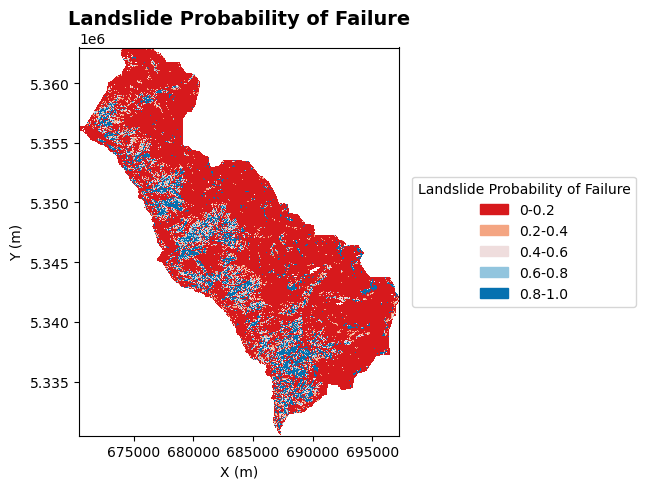

In [81]:
plot_node_custom(
    grid,
    "landslide__probability_of_failure",
    title="Landslide Probability of Failure",
    units="Landslide Probability of Failure",
    breaks=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    colors=["#d7191c", "#f4a582", "#EFDDDD", "#92c5de", "#0571b0"],
    labels=["0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"],
)


In [76]:
routed_recharge_max = route_recharge_field(
    grid,
    max_recharge,
    fill_sinks=False,
)
_=grid.add_field('routed_recharge_max', routed_recharge_max, at='node', clobber=True)

_=grid.add_field('groundwater__recharge_mean', routed_recharge_max, at='node', clobber=True)
grid['node']['groundwater__recharge_mean'][grid['node']['groundwater__recharge_mean'] <= 0] = 0.01

_=grid.add_field('groundwater__recharge_standard_deviation', grid.at_node['groundwater__recharge_mean']*0.1, at='node',clobber=True)

_=grid.add_field('groundwater__runoff_mean', max_runoff , at='node', clobber=True)
_=grid.add_field('mean_runoff', mean_runoff , at='node', clobber=True)
_=grid.add_field('mean_recharge', mean_recharge , at='node', clobber=True)
_=grid.add_field('max_recharge', max_recharge , at='node', clobber=True)

In [77]:
def post_fire_cohesion(t, c_pre, burn):
    reduction = np.ones_like(c_pre, dtype=float)
    reduction[burn == 2] = 1
    reduction[burn == 3] = 1
    reduction[burn == 4] = 1
    return c_pre * reduction

C_mode = post_fire_cohesion(t, grid.at_node["soil__mode_total_cohesion"], grid.at_node["burn__severity"])
C_min  = post_fire_cohesion(t, grid.at_node["soil__minimum_total_cohesion"], grid.at_node["burn__severity"])
C_max  = post_fire_cohesion(t, grid.at_node["soil__maximum_total_cohesion"], grid.at_node["burn__severity"])

grid.add_field("soil__mode_total_cohesion", grid.at_node["soil__mode_total_cohesion"], at="node", clobber=True)
grid.add_field("soil__minimum_total_cohesion", grid.at_node["soil__minimum_total_cohesion"], at="node", clobber=True)
grid.add_field("soil__maximum_total_cohesion", grid.at_node["soil__maximum_total_cohesion"], at="node", clobber=True)

array([-9999., -9999., -9999., ..., -9999., -9999., -9999.],
      shape=(968905,))

In [78]:
r = max_recharge.copy()
r[r <= 0] = 0.01
rstd = r * 0.1

n_iter = 1000

grid.add_field("groundwater__recharge_mean", r, at="node", clobber=True)
grid.add_field("groundwater__recharge_standard_deviation", rstd, at="node", clobber=True)
# grid.add_field("groundwater__runoff_mean", max_runoff, at="node", clobber=True)
grid.add_field("test_runoff", mean_runoff, at="node", clobber=True)
grid.add_field("test_recharge", mean_recharge, at="node", clobber=True)

LS_prob = LandslideProbability(
    grid,
    number_of_iterations=n_iter,
    groundwater__recharge_distribution="lognormal_spatial",
    groundwater__recharge_mean=r,
    groundwater__recharge_standard_deviation=rstd,
)
LS_prob.calculate_landslide_probability()

/home/abdullah/miniconda3/envs/ml_debris/lib/python3.10/site-packages/landlab/components/landslides/landslide_probability.py:579: RuntimeWarning: divide by zero encountered in scalar divide
  self._a / np.sin(np.arctan(self._theta))
/home/abdullah/miniconda3/envs/ml_debris/lib/python3.10/site-packages/landlab/components/landslides/landslide_probability.py:594: RuntimeWarning: divide by zero encountered in divide
  self._FS = (self._C_dim / np.sin(np.arctan(self._theta))) + (
/home/abdullah/miniconda3/envs/ml_debris/lib/python3.10/site-packages/landlab/components/landslides/landslide_probability.py:595: RuntimeWarning: divide by zero encountered in divide
  np.cos(np.arctan(self._theta)) * (Y / np.sin(np.arctan(self._theta)))


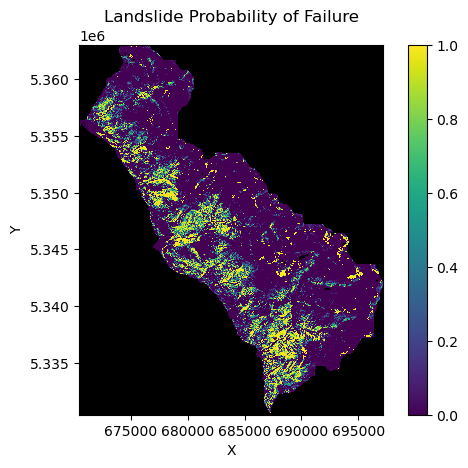

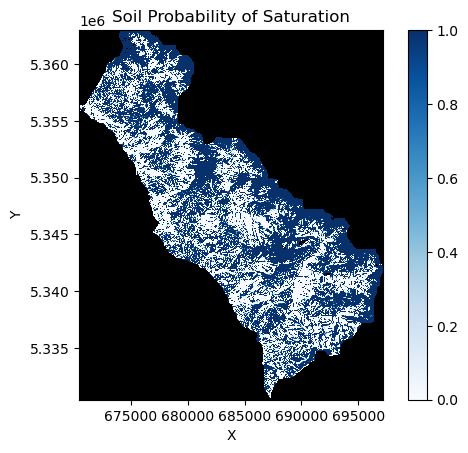

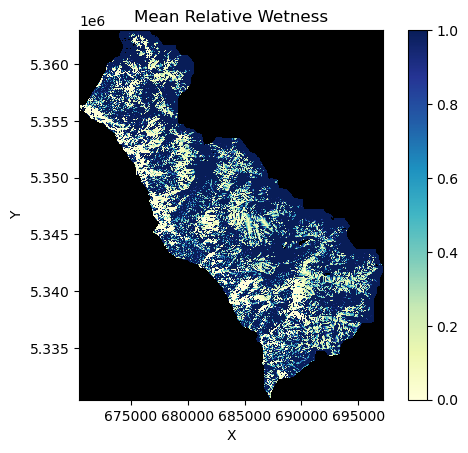

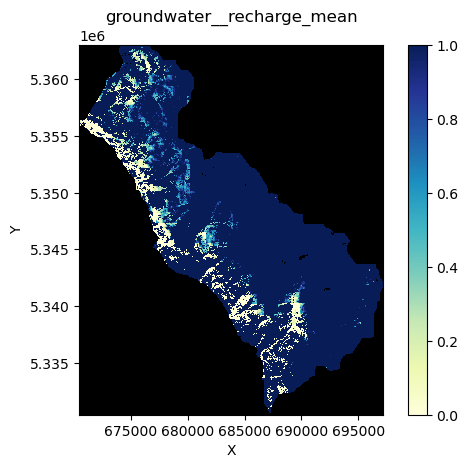

In [79]:
imshow_grid_at_node(grid, "landslide__probability_of_failure", cmap="viridis", limits=(0, 1))
plt.title("Landslide Probability of Failure")
plt.show()

imshow_grid_at_node(grid, "soil__probability_of_saturation", cmap="Blues", limits=(0, 1))
plt.title("Soil Probability of Saturation")
plt.show()

imshow_grid_at_node(grid, "soil__mean_relative_wetness", cmap="YlGnBu", limits=(0, 1))
plt.title("Mean Relative Wetness")
plt.show()

imshow_grid_at_node(grid, "groundwater__recharge_mean", cmap="YlGnBu", limits=(0, 1))
plt.title("groundwater__recharge_mean")
plt.show()

### Diagnostic Map: Runoff
Visualize the spatial runoff summary field to identify hotspots and routing patterns after the daily hydro-eco simulation.


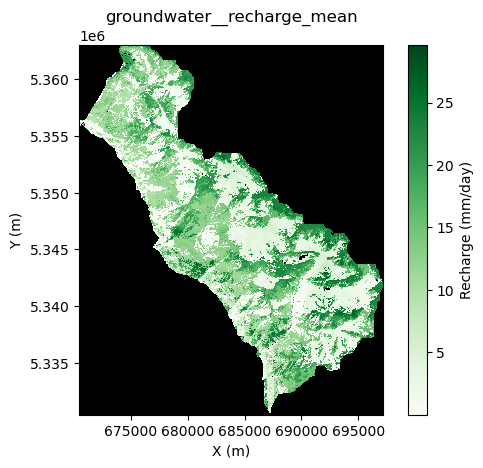

In [ ]:
# imshow_grid_at_node(grid,'test_runoff', plot_name = 'mean_runoff',
#             var_name = 'runoff', var_units = 'mm/day', grid_units = ('m','m'),
#             cmap = 'Greens') 

imshow_grid_at_node(grid,'groundwater__recharge_mean', plot_name = 'Maximum Recharge',
            var_name = 'Recharge', var_units = 'mm/day', grid_units = ('m','m'),
            cmap = 'Greens')

# imshow_grid_at_node(grid,'test_recharge', plot_name = 'Maximum Recharge',
#             var_name = 'Recharge', var_units = 'mm/day', grid_units = ('m','m'),
#             cmap = 'Greens')


# imshow_grid_at_node(grid,'max_recharge', plot_name = 'max_recharge',
#             var_name = 'Recharge', var_units = 'mm/day', grid_units = ('m','m'),
#             cmap = 'Greens')



### Route Maximum Recharge and Run Monte Carlo
Route the maximum local recharge field with D8 flow accumulation to compute an upslope-area-averaged recharge field, then use that routed recharge in `LandslideProbability`. If alternative recharge representations are tested, such as local versus routed recharge, that choice should be stated explicitly because it changes the physical interpretation of the landslide forcing.


In [93]:
recharge_for_ls = grid.at_node['groundwater__recharge_mean']
recharge_std_for_ls = grid.at_node['groundwater__recharge_standard_deviation']

recharge_for_ls

array([0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01], shape=(968905,))

In [88]:
# recharge_for_ls = grid.at_node['groundwater__recharge_mean']
# recharge_std_for_ls = grid.at_node['groundwater__recharge_standard_deviation']

# #C_mode = post_fire_cohesion(t, grid.at_node['soil__mode_total_cohesion_pre'], grid.at_node['burn__severity'])
# #C_min = post_fire_cohesion(t, grid.at_node['soil__minimum_total_cohesion_pre'], grid.at_node['burn__severity'])
# #C_max = post_fire_cohesion(t, grid.at_node['soil__maximum_total_cohesion_pre'], grid.at_node['burn__severity'])

# number_of_iterations = 1000

# LS_prob = LandslideProbability(
#     grid,
#     number_of_iterations=number_of_iterations,
#     groundwater__recharge_distribution='lognormal_spatial',
#     groundwater__recharge_mean=recharge_for_ls,
#     groundwater__recharge_standard_deviation=recharge_std_for_ls,
# )

# LS_prob.calculate_landslide_probability()

# print('run done')

Summarize Landslide Outputs
List generated landslide and saturation fields and print core-node statistics for probability of failure and wetness diagnostics.


In [50]:
# pip install rasterio

In [89]:
# 1) See what landslide outputs were created
print([k for k in grid.at_node.keys() if "landslide" in k or "saturation" in k or "wetness" in k])

# 2) Quick stats on core nodes
core = grid.core_nodes
pf = grid.at_node["landslide__probability_of_failure"]
ps = grid.at_node["soil__probability_of_saturation"]
mw = grid.at_node["soil__mean_relative_wetness"]

print("Pf mean/min/max:", pf[core].mean(), pf[core].min(), pf[core].max())
print("Ps mean/min/max:", ps[core].mean(), ps[core].min(), ps[core].max())
print("Wetness mean/min/max:", mw[core].mean(), mw[core].min(), mw[core].max())

['soil_moisture__initial_saturation_fraction', 'soil__mean_relative_wetness', 'landslide__probability_of_failure', 'soil__probability_of_saturation']
Pf mean/min/max: 0.14941713497061054 0.0 1.0
Ps mean/min/max: 0.3920720161015078 0.0 1.0
Wetness mean/min/max: 0.4996098762462473 8.280210123324988e-05 1.0


### Plot Daily Flux Time Series
Aggregate daily core-node recharge and runoff and plot time series for event-scale hydrologic interpretation.


In [52]:
recharge_arrays
# runoff_arrays

[array([0., 0., 0., ..., 0., 0., 0.], shape=(968905,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(968905,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(968905,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(968905,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(968905,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(968905,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(968905,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(968905,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(968905,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(968905,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(968905,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(968905,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(968905,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(968905,))]

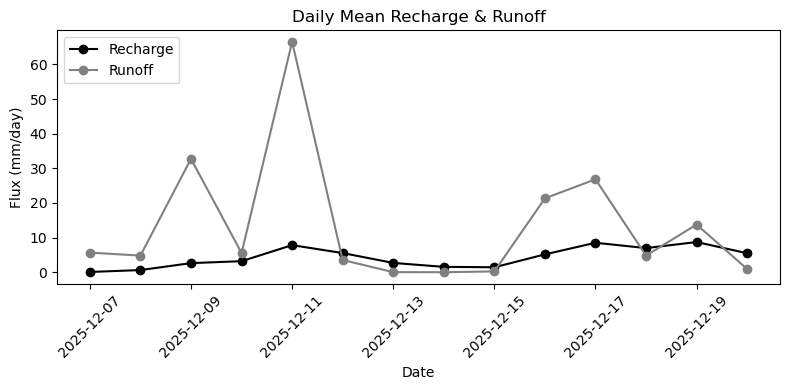

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

# --- Example inputs ---
core_nodes = grid.core_nodes

# Compute daily means
daily_mean_recharge = np.array([np.mean(arr[core_nodes]) for arr in recharge_arrays])
daily_mean_runoff   = np.array([np.mean(arr[core_nodes]) for arr in runoff_arrays])

# Dates for x-axis
dates = pd.date_range("2025-12-07", "2025-12-20")  

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(dates, daily_mean_recharge, '-o', color='black', label="Recharge")
ax.plot(dates, daily_mean_runoff, '-o', color='gray', label="Runoff")

ax.set_xlabel("Date")
ax.set_ylabel("Flux (mm/day)")
ax.set_title("Daily Mean Recharge & Runoff")

# Styling
ax.tick_params(axis='x', rotation=45)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import sys
from pathlib import Path

REPO_ROOT = Path("/home/abdullah/landlab_debrisflow")
SRC_DIR = REPO_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from prism_forcing import build_prism_daily_inputs

In [9]:
AOI_PATH = Path("/mnt/c/Users/amehedi/Downloads/pioneer/huc_pioneer1.shp")
EXPECTED_DATES = pd.date_range("2025-12-07", "2025-12-20", freq="D")

base_dir = Path.cwd()

prism_result = build_prism_daily_inputs(
    start_date=EXPECTED_DATES[0],
    end_date=EXPECTED_DATES[-1],
    dem_path=dem_path,
    dem_crs="EPSG:32610",
    aoi_path=AOI_PATH,
    out_dir=base_dir / "prism_forcing",
    region="us",
    resolution="800m",
    check_release_dates=True,
    force_download=False,
    sleep_seconds=2.0,
)

forcing_df = prism_result.forcing_df.copy()
rainfall_arrays = prism_result.rainfall_arrays
tempmin_arrays = prism_result.tempmin_arrays
tempmax_arrays = prism_result.tempmax_arrays

if len(forcing_df) != len(EXPECTED_DATES):
    raise ValueError(
        f"Expected {len(EXPECTED_DATES)} daily records, found {len(forcing_df)}"
    )

if list(forcing_df["datetime"]) != list(EXPECTED_DATES):
    raise ValueError("Forcing dates do not match the requested storm window.")

Tmin_o = forcing_df["tmin_c"].tolist()
Tmax_o = forcing_df["tmax_c"].tolist()
P_obs = forcing_df["precip_mm"].tolist()

forcing_df[["datetime", "precip_mm", "tmin_c", "tmax_c"]]

,datetime,precip_mm,tmin_c,tmax_c
0,2025-12-07,21.690404,-2.151717,0.714271
1,2025-12-08,20.649575,-2.138510,0.786861
2,2025-12-09,58.043269,-1.500268,2.227234
3,2025-12-10,22.023621,-2.632602,1.952618
4,2025-12-11,95.330834,-0.006590,6.012244
5,2025-12-12,17.568185,-1.440721,3.224879
6,2025-12-13,3.111454,0.120609,4.295637
7,2025-12-14,0.000000,0.695569,7.366581
8,2025-12-15,5.565217,1.641938,5.440714
9,2025-12-16,44.325544,-1.074730,5.344322


In [10]:
print(len(rainfall_arrays), len(tempmin_arrays), len(tempmax_arrays))
print(rainfall_arrays[0].shape, tempmin_arrays[0].shape, tempmax_arrays[0].shape)
print(prism_result.csv_path)

14 14 14
(968905,) (968905,) (968905,)
/mnt/c/Users/amehedi/Downloads/ml_debris/pioneer/output/cut1/prism_forcing/forcing_daily_prism.csv


In [12]:
prism_daily_asc_dir = asc_dir / "prism_daily_asc"
ppt_dir = prism_daily_asc_dir / "ppt"
tmin_dir = prism_daily_asc_dir / "tmin"
tmax_dir = prism_daily_asc_dir / "tmax"

ppt_dir.mkdir(parents=True, exist_ok=True)
tmin_dir.mkdir(parents=True, exist_ok=True)
tmax_dir.mkdir(parents=True, exist_ok=True)

with open(dem_path, "r") as f:
    dem_header_lines = [next(f).rstrip("\n") for _ in range(6)]

dem_nodata = float(dem_header_lines[5].split()[-1])
nrows, ncols = grid.shape

def write_like_dem_asc(node_values, out_path):
    arr = np.asarray(node_values, dtype=float).reshape((nrows, ncols))
    arr = np.where(np.isfinite(arr), arr, dem_nodata)

    with open(out_path, "w") as f:
        f.write("\n".join(dem_header_lines) + "\n")
        for row in arr:
            f.write(" ".join(map(str, row)) + "\n")

ppt_asc_paths = []
tmin_asc_paths = []
tmax_asc_paths = []

for dt, rainfall, tmin_arr, tmax_arr in zip(
    forcing_df["datetime"], rainfall_arrays, tempmin_arrays, tempmax_arrays
):
    day = pd.Timestamp(dt).strftime("%Y%m%d")

    ppt_path = ppt_dir / f"precip_{day}.asc"
    tmin_path = tmin_dir / f"tmin_{day}.asc"
    tmax_path = tmax_dir / f"tmax_{day}.asc"

    write_like_dem_asc(rainfall, ppt_path)
    write_like_dem_asc(tmin_arr, tmin_path)
    write_like_dem_asc(tmax_arr, tmax_path)

    ppt_asc_paths.append(ppt_path)
    tmin_asc_paths.append(tmin_path)
    tmax_asc_paths.append(tmax_path)

print("ppt files:", len(ppt_asc_paths))
print("tmin files:", len(tmin_asc_paths))
print("tmax files:", len(tmax_asc_paths))
print("last ppt file:", ppt_asc_paths[-1])

ppt files: 14
tmin files: 14
tmax files: 14
last ppt file: /mnt/c/Users/amehedi/Downloads/ml_debris/pioneer/output/cut1/prism_daily_asc/ppt/precip_20251220.asc
